# Trabajo Práctico Integral: Ciencia de Datos
## Segunda Entrega: Proceso ETL y Calidad de Datos

**Institución:** Universidad Tecnológica Nacional – Facultad Regional Córdoba
**Cátedra:** Ciencia de Datos
**Grupo:** 10
**Fecha:** Mayo 2026

---
### 🎯 Objetivo de esta Etapa
Preparar un dataset consistente y libre de sesgos técnicos para predecir el **Método de Descubrimiento** (`discoverymethod`) de exoplanetas, basándonos exclusivamente en atributos físicos, orbitales y estelares.

## 1. Carga de Datos y Configuración
En esta sección cargamos las librerías necesarias y el dataset original del *NASA Exoplanet Archive*. Definimos la configuración de visualización para asegurar la trazabilidad de todas las columnas.

In [11]:
from IPython import display
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display as mostrar

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# ------------------------------------------------------------
# 3. Cargar dataset raw
# ------------------------------------------------------------

RAW_PATH = "../Data/NASA_Exoplanet_Archive_Data.csv"

df_raw = pd.read_csv(RAW_PATH)

print("Dataset cargado correctamente.")
print(f"Filas originales: {df_raw.shape[0]}")
print(f"Columnas originales: {df_raw.shape[1]}")

df_raw.head()

Dataset cargado correctamente.
Filas originales: 36418
Columnas originales: 91


,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_refname,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,pl_radj,pl_radjerr1,pl_radjerr2,pl_radjlim,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_bmasselim,pl_bmassj,pl_bmassjerr1,pl_bmassjerr2,pl_bmassjlim,pl_bmassprov,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccenlim,pl_insol,pl_insolerr1,pl_insolerr2,pl_insollim,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtlim,ttv_flag,st_refname,st_spectype,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_rad,st_raderr1,st_raderr2,st_radlim,st_mass,st_masserr1,st_masserr2,st_masslim,st_met,st_meterr1,st_meterr2,st_metlim,st_metratio,st_logg,st_loggerr1,st_loggerr2,st_logglim,sy_refname,rastr,ra,decstr,dec,sy_dist,sy_disterr1,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,https://ui.adsabs.harvard.edu/abs/2011ApJ...73...,NaN,NaN,NaN,NaN,1.2100,0.0600,-0.0500,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5434.7000,540.3000,-413.2000,0.0000,17.1000,1.7000,-1.3000,0.0000,Msini,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,https://ui.adsabs.harvard.edu/abs/2011ApJ...73...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.6000,0.4000,-0.3000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://ui.adsabs.harvard.edu/abs/2019AJ....15...,12h20m42.91s,185.1788,+17d47m35.71s,17.7933,93.1846,1.9238,-1.9238,4.7231,0.0230,-0.0230,2.2820,0.3460,-0.3460,4.4404,0.0038,-0.0038,2014-07-23,2011-08,2014-07-23
1,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,https://ui.adsabs.harvard.edu/abs/2008ApJ...67...,326.0300,0.3200,-0.3200,0.0000,1.2900,0.0500,-0.0500,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6165.6000,476.7000,-476.7000,0.0000,19.4000,1.5000,-1.5000,0.0000,Msini,0.2310,0.0050,-0.0050,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,https://ui.adsabs.harvard.edu/abs/2008ApJ...67...,G8 III,4742.0000,100.0000,-100.0000,0.0000,19.0000,2.0000,-2.0000,0.0000,2.7000,0.3000,-0.3000,0.0000,-0.3500,0.0900,-0.0900,0.0000,[Fe/H],2.3100,0.1000,-0.1000,0.0000,https://ui.adsabs.harvard.edu/abs/2019AJ....15...,12h20m42.91s,185.1788,+17d47m35.71s,17.7933,93.1846,1.9238,-1.9238,4.7231,0.0230,-0.0230,2.2820,0.3460,-0.3460,4.4404,0.0038,-0.0038,2014-05-14,2008-01,2014-05-14
2,11 Com b,11 Com,1,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,https://ui.adsabs.harvard.edu/abs/2023arXiv230...,323.2100,0.0600,-0.0500,0.0000,1.1780,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4914.8985,39.0929,-39.7285,0.0000,15.4640,0.1230,-0.1250,0.0000,Msini,0.2380,0.0070,-0.0070,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,https://ui.adsabs.harvard.edu/abs/2023arXiv230...,G8 III,4874.0000,NaN,NaN,0.0000,13.7600,2.8500,-2.4500,0.0000,2.0900,0.6400,-0.6300,0.0000,-0.2600,0.1000,-0.1000,0.0000,[Fe/H],2.4500,0.0800,-0.0800,0.0000,https://ui.adsabs.harvard.edu/abs/2019AJ....15...,12h20m42.91s,185.1788,+17d47m35.71s,17.7933,93.1846,1.9238,-1.9238,4.7231,0.0230,-0.0230,2.2820,0.3460,-0.3460,4.4404,0.0038,-0.0038,2023-09-19,2023-08,2023-09-19
3,11 UMi b,11 UMi,1,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,https://ui.adsabs.harvard.edu/abs/2017AJ....15...,516.2200,3.2000,-3.2000,0.0000,1.5300,0.0700,-0.0700,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4684.8142,794.5750,-794.5750,0.0000,14.7400,2.5000,-2.5000,0.0000,Msini,0.0800,0.0300,-0.0300,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,https://ui.adsabs.harvard.edu/abs/2017AJ....15...,NaN,4213.0000,46.0000,-46.0000,0.0000,29.7900,2.8400,-2.8400,0.0000,2.7800,0.6900,-0.6900,0.0000,-0.0200,NaN,NaN,0.0000,[Fe/H],1.9300,0.0700,-0.0700,0.0000,https://ui.adsabs.harvard.edu/abs/2019AJ....15...,15h17m05.90s,229.2746,+71d49m26.19s,71.8239,125.3210,1.9765,-1.9765,5.0130,0.0050,-0.0050,1.

## 2. Validación del Target y Limpieza Inicial
Filtramos los registros canónicos (`default_flag = 1`) para evitar duplicar planetas por distintas publicaciones, diagnosticamos la estructura y eliminamos las filas que no poseen el dato que queremos predecir (nuestro target).

Dimensiones del dataset original:
(36418, 91)

Tipos de datos:


pl_name                str
hostname               str
default_flag         int64
sy_snum              int64
sy_pnum              int64
discoverymethod        str
disc_year            int64
disc_facility          str
soltype                str
pl_refname             str
pl_orbper          float64
pl_orbpererr1      float64
pl_orbpererr2      float64
pl_orbperlim       float64
pl_orbsmax         float64
pl_orbsmaxerr1     float64
pl_orbsmaxerr2     float64
pl_orbsmaxlim      float64
pl_rade            float64
pl_radeerr1        float64
pl_radeerr2        float64
pl_radelim         float64
pl_radj            float64
pl_radjerr1        float64
pl_radjerr2        float64
pl_radjlim         float64
pl_bmasse          float64
pl_bmasseerr1      float64
pl_bmasseerr2      float64
pl_bmasselim       float64
pl_bmassj          float64
pl_bmassjerr1      float64
pl_bmassjerr2      float64
pl_bmassjlim       float64
pl_bmassprov           str
pl_orbeccen        float64
pl_orbeccenerr1    float64
p


Estadísticas descriptivas generales:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pl_name,36418,5757,TrES-2 b,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hostname,36418,4316,Kepler-11,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default_flag,36418.0000,NaN,NaN,NaN,0.1581,0.3648,0.0000,0.0000,0.0000,0.0000,1.0000
sy_snum,36418.0000,NaN,NaN,NaN,1.0858,0.3102,1.0000,1.0000,1.0000,1.0000,4.0000
sy_pnum,36418.0000,NaN,NaN,NaN,1.8818,1.2034,1.0000,1.0000,1.0000,2.0000,8.0000
discoverymethod,36418,11,Transit,32841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disc_year,36418.0000,NaN,NaN,NaN,2015.4133,3.8994,1992.0000,2014.0000,2016.0000,2016.0000,2024.0000
disc_facility,36418,70,Kepler,26755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soltype,36418,9,Published Confirmed,18702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pl_refname,36418,2221,https://exoplanetarchive.ipac.caltech.edu/docs...,15840,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Columnas disponibles:
pl_name
hostname
default_flag
sy_snum
sy_pnum
discoverymethod
disc_year
disc_facility
soltype
pl_refname
pl_orbper
pl_orbpererr1
pl_orbpererr2
pl_orbperlim
pl_orbsmax
pl_orbsmaxerr1
pl_orbsmaxerr2
pl_orbsmaxlim
pl_rade
pl_radeerr1
pl_radeerr2
pl_radelim
pl_radj
pl_radjerr1
pl_radjerr2
pl_radjlim
pl_bmasse
pl_bmasseerr1
pl_bmasseerr2
pl_bmasselim
pl_bmassj
pl_bmassjerr1
pl_bmassjerr2
pl_bmassjlim
pl_bmassprov
pl_orbeccen
pl_orbeccenerr1
pl_orbeccenerr2
pl_orbeccenlim
pl_insol
pl_insolerr1
pl_insolerr2
pl_insollim
pl_eqt
pl_eqterr1
pl_eqterr2
pl_eqtlim
ttv_flag
st_refname
st_spectype
st_teff
st_tefferr1
st_tefferr2
st_tefflim
st_rad
st_raderr1
st_raderr2
st_radlim
st_mass
st_masserr1
st_masserr2
st_masslim
st_met
st_meterr1
st_meterr2
st_metlim
st_metratio
st_logg
st_loggerr1
st_loggerr2
st_logglim
sy_refname
rastr
ra
decstr
dec
sy_dist
sy_disterr1
sy_disterr2
sy_vmag
sy_vmagerr1
sy_vmagerr2
sy_kmag
sy_kmagerr1
sy_kmagerr2
sy_gaiamag
sy_gaiamagerr1
sy_gaiamagerr2
r

discoverymethod
Transit                          32841
Radial Velocity                   2544
Microlensing                       689
Imaging                            145
Transit Timing Variations          142
Eclipse Timing Variations           22
Orbital Brightness Modulation       16
Pulsar Timing                       13
Astrometry                           3
Pulsation Timing Variations          2
Disk Kinematics                      1
Name: count, dtype: int64

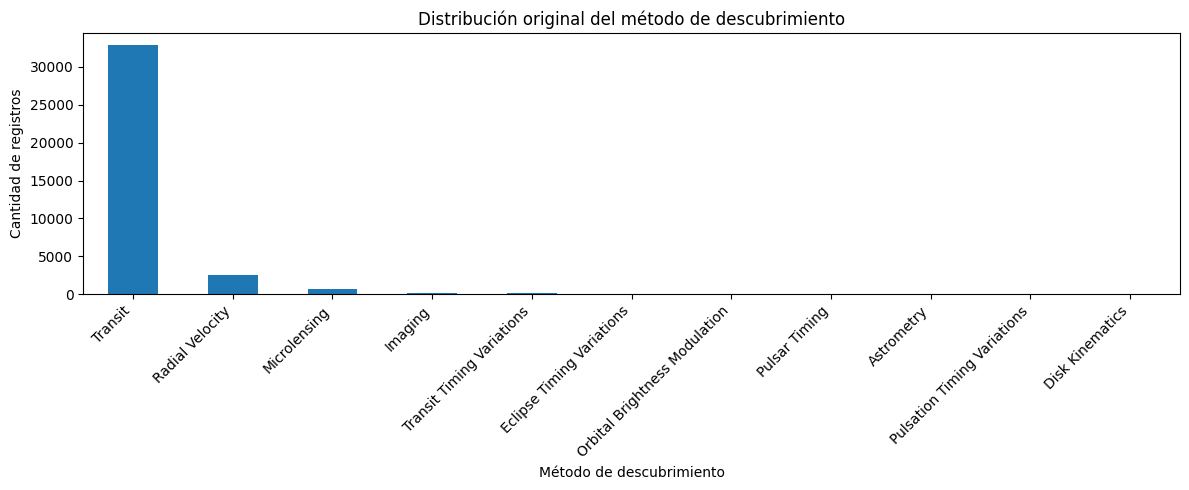


Distribución de discoverymethod luego del filtrado:


discoverymethod
Transit                          4304
Radial Velocity                  1080
Microlensing                      230
Imaging                            79
Transit Timing Variations          31
Eclipse Timing Variations          15
Pulsar Timing                       8
Orbital Brightness Modulation       4
Astrometry                          3
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64

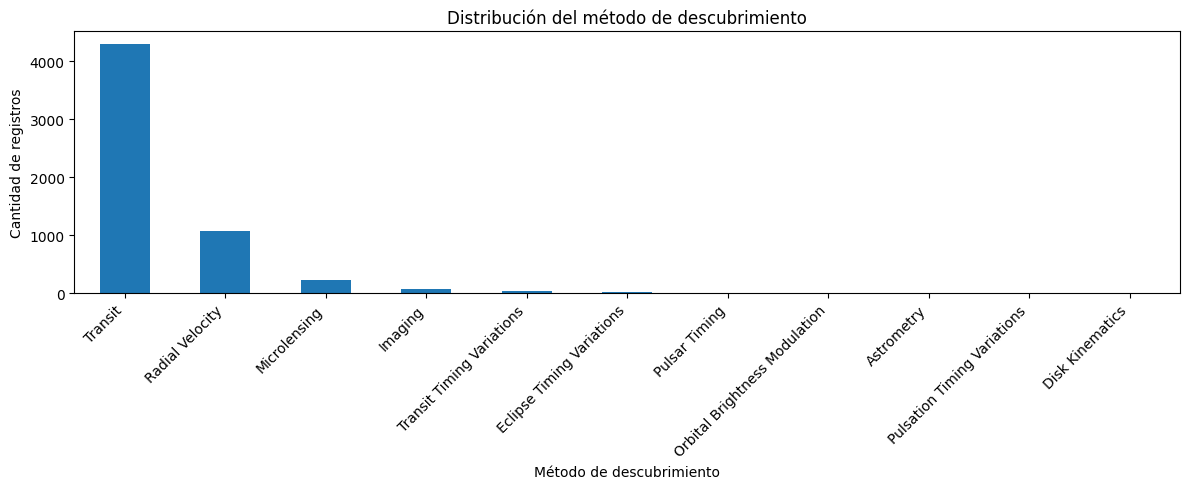


Después del filtro default_flag = 1:
Filas: 5757
Planetas únicos: 5757

Planetas duplicados luego del filtro:


Series([], Name: count, dtype: int64)


Filas antes de eliminar target nulo: 5757
Filas después de eliminar target nulo: 5757
Filas eliminadas: 0


In [18]:
# ------------------------------------------------------------
# 4. Diagnosticar estructura inicial
# ------------------------------------------------------------

print("Dimensiones del dataset original:")
print(df_raw.shape)

print("\nTipos de datos:")
mostrar(df_raw.dtypes)

print("\nEstadísticas descriptivas generales:")
mostrar(df_raw.describe(include="all").T)

print("\nColumnas disponibles:")
for col in df_raw.columns:
    print(col)

# ------------------------------------------------------------
# 5. Validar variable objetivo: discoverymethod
# ------------------------------------------------------------

TARGET = "discoverymethod"

if TARGET not in df_raw.columns:
    raise ValueError(f"No existe la columna objetivo: {TARGET}")

print(f"\nColumna objetivo encontrada: {TARGET}")

print("\nNulos en discoverymethod:")
print(df_raw[TARGET].isnull().sum())

print("\nDistribución original de discoverymethod:")
target_counts_raw = df_raw[TARGET].value_counts(dropna=False)
mostrar(target_counts_raw)

plt.figure(figsize=(12, 5))
target_counts_raw.plot(kind="bar")
plt.title("Distribución original del método de descubrimiento")
plt.xlabel("Método de descubrimiento")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Filtrar default_flag = 1
# ------------------------------------------------------------

df = df_raw.copy()


df = df[df["default_flag"] == 1].copy()
df = df.reset_index(drop=True)


duplicados = df["pl_name"].value_counts()
duplicados = duplicados[duplicados > 1]



# ------------------------------------------------------------
# 7. Eliminar filas sin target
# ------------------------------------------------------------

filas_antes = len(df)

df = df.dropna(subset=[TARGET]).copy()

filas_despues = len(df)

print("\nDistribución de discoverymethod luego del filtrado:")
target_counts = df[TARGET].value_counts(dropna=False)
mostrar(target_counts)

plt.figure(figsize=(12, 5))
target_counts.plot(kind="bar")
plt.title("Distribución del método de descubrimiento")
plt.xlabel("Método de descubrimiento")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


print("\nDespués del filtro default_flag = 1:")
print(f"Filas: {len(df)}")
print(f"Planetas únicos: {df['pl_name'].nunique()}")
print("\nPlanetas duplicados luego del filtro:")
mostrar(duplicados)
print(f"\nFilas antes de eliminar target nulo: {filas_antes}")
print(f"Filas después de eliminar target nulo: {filas_despues}")
print(f"Filas eliminadas: {filas_antes - filas_despues}")

## 3. Mitigación de Fuga de Información (Data Leakage)
Paso crítico: Eliminamos identificadores, metadatos y **variables asociadas al proceso de descubrimiento** (`disc_year`, `disc_facility`). Si el modelo aprende que un año específico corresponde a un telescopio particular, memorizará el método en lugar de aprender la física.

In [13]:
# ------------------------------------------------------------
# 8. Clasificar columnas por tipo
# ------------------------------------------------------------

# Identificadores: no generalizan para nuevos planetas
id_cols = [
    "pl_name",
    "hostname"
]

# Metadatos y referencias bibliográficas
metadata_cols = [
    "pl_refname",
    "st_refname",
    "sy_refname",
    "rowupdate",
    "pl_pubdate",
    "releasedate",
    "soltype"
]

# Variables asociadas directamente al proceso de descubrimiento.
discovery_process_cols = [
    "disc_year",
    "disc_facility"
]

# Coordenadas en formato texto; se conservan ra y dec en numérico
coord_text_cols = [
    "rastr",
    "decstr"
]

# Columnas de error e incertidumbre
error_cols = [
    col for col in df.columns
    if col.endswith("err1") or col.endswith("err2")
]

# Columnas de límite o flags técnicos de medición
lim_cols = [
    col for col in df.columns
    if col.endswith("lim")
]

# Duplicados de unidades
redundant_unit_cols = [
    "pl_radj",
    "pl_bmassj"
]

# Columnas técnicas ya usadas o potencialmente no predictivas
technical_cols = [
    "default_flag",
    "ttv_flag",
    "pl_bmassprov",
    "st_metratio"
]

cols_to_drop = (
    id_cols
    + metadata_cols
    + discovery_process_cols
    + coord_text_cols
    + error_cols
    + lim_cols
    + redundant_unit_cols
    + technical_cols
)

cols_to_drop = [col for col in cols_to_drop if col in df.columns]

print("Columnas identificadoras:", id_cols)
print("Columnas de metadatos:", metadata_cols)
print("Columnas del proceso de descubrimiento:", discovery_process_cols)
print("Columnas de error:", len(error_cols))
print("Columnas de límite:", len(lim_cols))
print("Columnas redundantes por unidad:", redundant_unit_cols)
print("Columnas técnicas:", technical_cols)

print(f"\nTotal de columnas a eliminar: {len(cols_to_drop)}")

# ------------------------------------------------------------
# 9. Eliminar columnas irrelevantes
# ------------------------------------------------------------

shape_antes = df.shape

df = df.drop(columns=cols_to_drop, errors="ignore")

shape_despues = df.shape

print(f"\nShape antes: {shape_antes}")
print(f"Shape después: {shape_despues}")

print("\nColumnas restantes:")
print(df.columns.tolist())

Columnas identificadoras: ['pl_name', 'hostname']
Columnas de metadatos: ['pl_refname', 'st_refname', 'sy_refname', 'rowupdate', 'pl_pubdate', 'releasedate', 'soltype']
Columnas del proceso de descubrimiento: ['disc_year', 'disc_facility']
Columnas de error: 36
Columnas de límite: 14
Columnas redundantes por unidad: ['pl_radj', 'pl_bmassj']
Columnas técnicas: ['default_flag', 'ttv_flag', 'pl_bmassprov', 'st_metratio']

Total de columnas a eliminar: 69

Shape antes: (5757, 91)
Shape después: (5757, 22)

Columnas restantes:
['sy_snum', 'sy_pnum', 'discoverymethod', 'pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'pl_orbeccen', 'pl_insol', 'pl_eqt', 'st_spectype', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_logg', 'ra', 'dec', 'sy_dist', 'sy_vmag', 'sy_kmag', 'sy_gaiamag']


## 4. Ingeniería de Datos: Ausencia Informativa (_missing)
En astronomía, la ausencia de una medición es informativa. Ciertos métodos (como Tránsito) rara vez miden la masa directamente. Creamos indicadores booleanos para capturar esta "firma" del método de descubrimiento antes de proceder a la imputación.

Columnas con valores nulos:


,nulos,porcentaje_nulos
pl_insol,5026,87.3024
st_spectype,4601,79.9201
pl_eqt,4306,74.7959
pl_orbeccen,3403,59.1106
pl_bmasse,3051,52.9964
pl_orbsmax,2220,38.5618
st_met,1710,29.7030
pl_rade,1415,24.5788
st_logg,984,17.0922
st_mass,751,13.0450


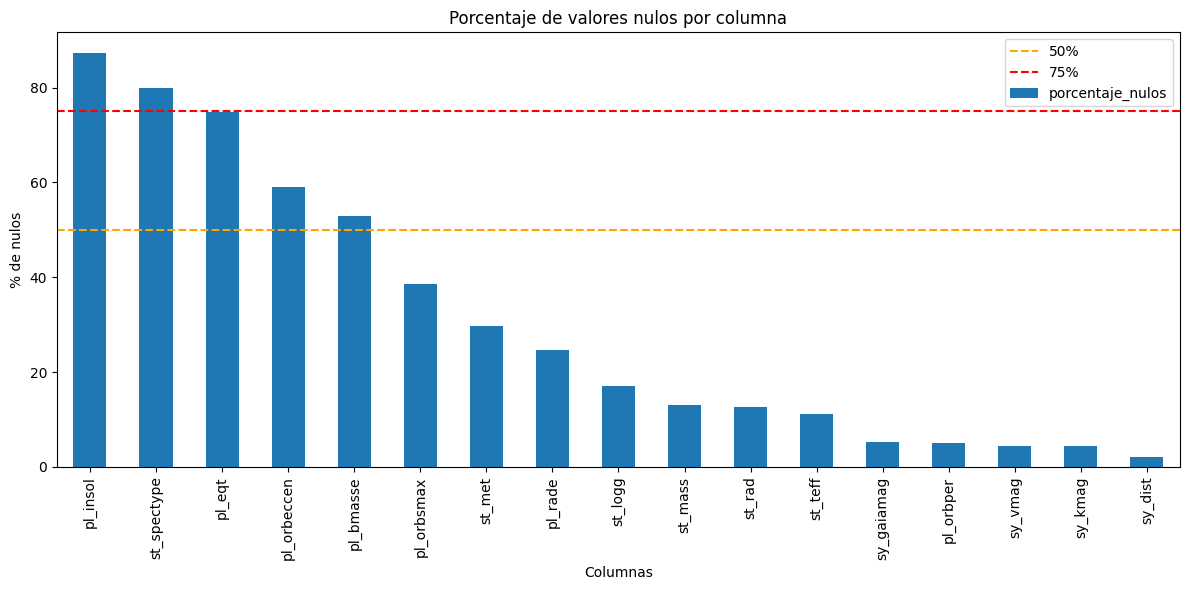

Columnas _missing creadas:
pl_bmasse_missing
pl_rade_missing
pl_orbper_missing
pl_orbsmax_missing
pl_orbeccen_missing
st_teff_missing
st_rad_missing
st_mass_missing
st_met_missing
st_logg_missing
sy_dist_missing
ra_missing
dec_missing


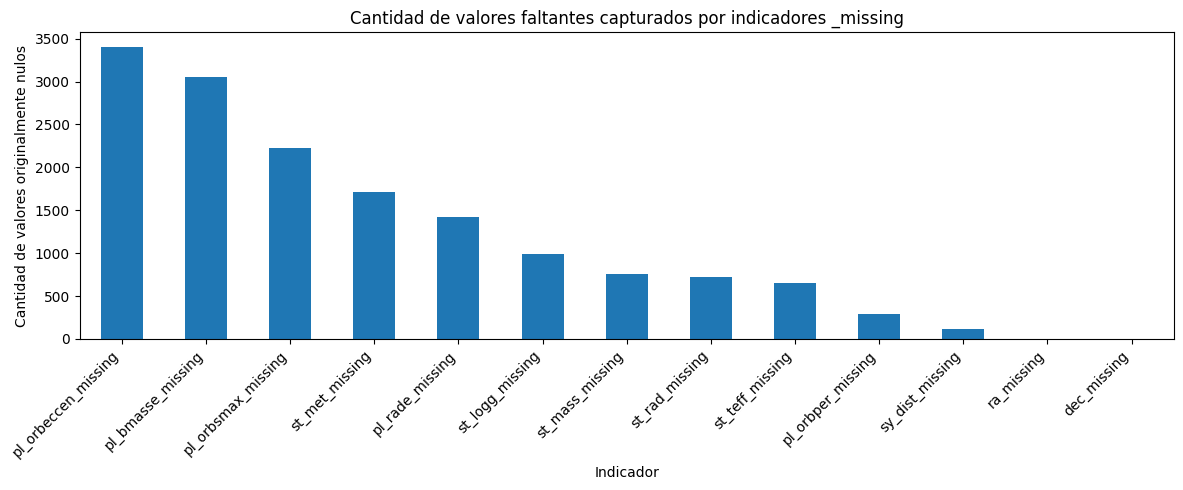

Columnas con más de 75% de nulos:
['pl_insol', 'st_spectype']

Columnas eliminadas por nulos excesivos:
['pl_insol', 'st_spectype']

Shape después de eliminar columnas de nulos excesivos:
(5757, 33)


In [14]:
# ------------------------------------------------------------
# 10. Analizar nulos
# ------------------------------------------------------------

null_summary = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje_nulos": df.isnull().mean() * 100
}).sort_values("porcentaje_nulos", ascending=False)

null_summary_nonzero = null_summary[null_summary["nulos"] > 0]

print("Columnas con valores nulos:")
mostrar(null_summary_nonzero)

plt.figure(figsize=(12, 6))
null_summary_nonzero["porcentaje_nulos"].plot(kind="bar")
plt.axhline(50, linestyle="--", label="50%", color="orange")
plt.axhline(75, linestyle="--", label="75%", color="red")
plt.title("Porcentaje de valores nulos por columna")
plt.xlabel("Columnas")
plt.ylabel("% de nulos")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Crear indicadores _missing para variables relevantes
# ------------------------------------------------------------

missing_signal_cols = [
    "pl_bmasse",     # masa del planeta
    "pl_rade",       # radio del planeta
    "pl_orbper",     # período orbital
    "pl_orbsmax",    # semieje mayor
    "pl_orbeccen",   # excentricidad
    "st_teff",       # temperatura efectiva de la estrella
    "st_rad",        # radio estelar
    "st_mass",       # masa estelar
    "st_met",        # metalicidad
    "st_logg",       # gravedad superficial
    "sy_dist",       # distancia del sistema
    "ra",            # ascensión recta
    "dec"            # declinación
]

missing_signal_cols = [col for col in missing_signal_cols if col in df.columns]

for col in missing_signal_cols:
    df[f"{col}_missing"] = df[col].isnull().astype(int)

print("Columnas _missing creadas:")
for col in missing_signal_cols:
    print(f"{col}_missing")

missing_indicators = [f"{col}_missing" for col in missing_signal_cols]
missing_counts = df[missing_indicators].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
missing_counts.plot(kind="bar")
plt.title("Cantidad de valores faltantes capturados por indicadores _missing")
plt.xlabel("Indicador")
plt.ylabel("Cantidad de valores originalmente nulos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Eliminar columnas con nulos excesivos no justificables
# ------------------------------------------------------------

high_null_cols = null_summary[
    null_summary["porcentaje_nulos"] > 75
].index.tolist()

# No eliminar target ni indicadores _missing
protected_cols = [TARGET] + missing_signal_cols + missing_indicators

cols_high_null_to_drop = [
    col for col in high_null_cols
    if col not in protected_cols
]

print("Columnas con más de 75% de nulos:")
print(high_null_cols)

print("\nColumnas eliminadas por nulos excesivos:")
print(cols_high_null_to_drop)

df = df.drop(columns=cols_high_null_to_drop, errors="ignore")

print("\nShape después de eliminar columnas de nulos excesivos:")
print(df.shape)

## 5. Consistencia Física e Imputación de Valores
Corregimos inconsistencias físicas (valores negativos donde no corresponden) e imputamos los nulos restantes. Utilizamos la **mediana global** para evitar usar el target (`discoverymethod`) en la imputación, previniendo así la fuga de información.

,columna,valores_negativos
0,pl_rade,0
1,pl_bmasse,0
2,pl_orbper,0
3,pl_orbsmax,0
4,pl_eqt,0
5,st_teff,0
6,st_rad,0
7,st_mass,0
8,sy_dist,0


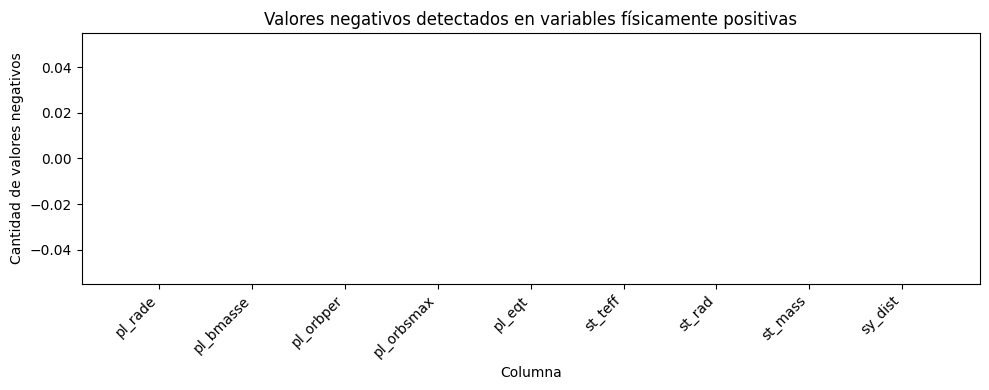

Imputación numérica realizada:


,columna,nulos_imputados,mediana_usada
0,pl_orbper,285,11.2670
1,pl_orbsmax,2220,0.1159
2,pl_rade,1415,2.4000
3,pl_bmasse,3051,187.5197
4,pl_orbeccen,3403,0.0860
5,pl_eqt,4306,903.0000
6,st_teff,646,5551.0000
7,st_rad,722,0.9500
8,st_mass,751,0.9500
9,st_met,1710,0.0200



Imputación categórica realizada:
No se encontraron valores nulos en columnas categóricas.


In [15]:
# ------------------------------------------------------------
# 13. Validar consistencia física básica
# ------------------------------------------------------------

positive_cols = [
    "pl_rade", "pl_bmasse", "pl_orbper", "pl_orbsmax",
    "pl_insol", "pl_eqt", "st_teff", "st_rad", "st_mass", "sy_dist"
]

positive_cols = [col for col in positive_cols if col in df.columns]

invalid_physical_summary = []

for col in positive_cols:
    invalid_count = (df[col] < 0).sum()
    invalid_physical_summary.append({
        "columna": col,
        "valores_negativos": invalid_count
    })

    if invalid_count > 0:
        df.loc[df[col] < 0, col] = np.nan

invalid_physical_summary = pd.DataFrame(invalid_physical_summary)
mostrar(invalid_physical_summary)

plt.figure(figsize=(10, 4))
plt.bar(
    invalid_physical_summary["columna"],
    invalid_physical_summary["valores_negativos"]
)
plt.title("Valores negativos detectados en variables físicamente positivas")
plt.xlabel("Columna")
plt.ylabel("Cantidad de valores negativos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 14. Imputar numéricas con mediana global
# ------------------------------------------------------------

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != TARGET]

imputation_numeric_summary = []

for col in numeric_cols:
    missing_count = df[col].isnull().sum()

    if missing_count > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

        imputation_numeric_summary.append({
            "columna": col,
            "nulos_imputados": missing_count,
            "mediana_usada": median_value
        })

imputation_numeric_summary = pd.DataFrame(imputation_numeric_summary)
print("Imputación numérica realizada:")
mostrar(imputation_numeric_summary)

# ------------------------------------------------------------
# 15. Imputar categóricas con Unknown
# ------------------------------------------------------------

categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != TARGET]

imputation_categorical_summary = []

for col in categorical_cols:
    missing_count = df[col].isnull().sum()

    if missing_count > 0:
        df[col] = df[col].fillna("Unknown")

        imputation_categorical_summary.append({
            "columna": col,
            "nulos_imputados": missing_count,
            "valor_usado": "Unknown"
        })

imputation_categorical_summary = pd.DataFrame(imputation_categorical_summary)

print("\nImputación categórica realizada:")
if imputation_categorical_summary.empty:
    print("No se encontraron valores nulos en columnas categóricas.")
else:
    mostrar(imputation_categorical_summary)

## 6. Agrupación de Clases y Transformaciones Logarítmicas
Dado el fuerte desbalance del target, agrupamos las clases minoritarias en `Other`. Además, aplicamos escala logarítmica (`log1p`) a variables de gran dispersión. Esto comprime la escala y nos permite documentar y **conservar los outliers** (descubrimientos anómalos reales).

Distribución antes de agrupar clases minoritarias:


discoverymethod
Transit                          4304
Radial Velocity                  1080
Microlensing                      230
Imaging                            79
Transit Timing Variations          31
Eclipse Timing Variations          15
Pulsar Timing                       8
Orbital Brightness Modulation       4
Astrometry                          3
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64


Clases agrupadas como Other: ['Imaging', 'Transit Timing Variations', 'Eclipse Timing Variations', 'Pulsar Timing', 'Orbital Brightness Modulation', 'Astrometry', 'Pulsation Timing Variations', 'Disk Kinematics']

Distribución después de agrupar clases minoritarias:


discoverymethod
Transit            4304
Radial Velocity    1080
Microlensing        230
Other               143
Name: count, dtype: int64

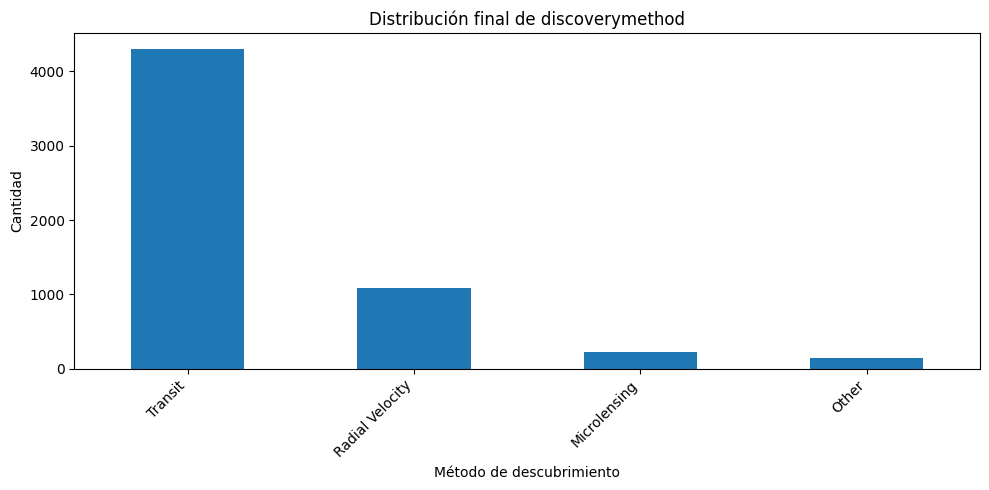


Top 20 columnas con más outliers:


,columna,outliers,porcentaje_outliers,limite_inferior,limite_superior
5,pl_bmasse,2702,46.9342,187.5197,187.5197
6,pl_orbeccen,2348,40.7851,0.0860,0.0860
7,pl_eqt,1449,25.1694,903.0000,903.0000
20,pl_rade_missing,1415,24.5788,0.0000,0.0000
3,pl_orbsmax,1161,20.1668,-0.0402,0.2938
11,st_met,1146,19.9062,-0.1650,0.1950
2,pl_orbper,1006,17.4744,-42.1942,82.5977
28,st_logg_missing,984,17.0922,0.0000,0.0000
4,pl_rade,942,16.3627,0.1350,4.7350
26,st_mass_missing,751,13.0450,0.0000,0.0000


Creada variable: pl_bmasse_log
Creada variable: pl_rade_log
Creada variable: pl_orbper_log
Creada variable: pl_orbsmax_log
Creada variable: pl_eqt_log
Creada variable: sy_dist_log
Creada variable: st_mass_log
Creada variable: st_rad_log
Creada variable: st_teff_log


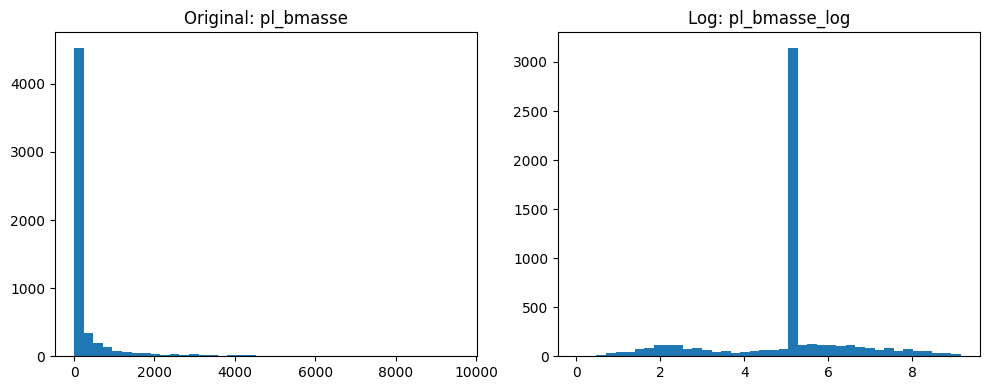

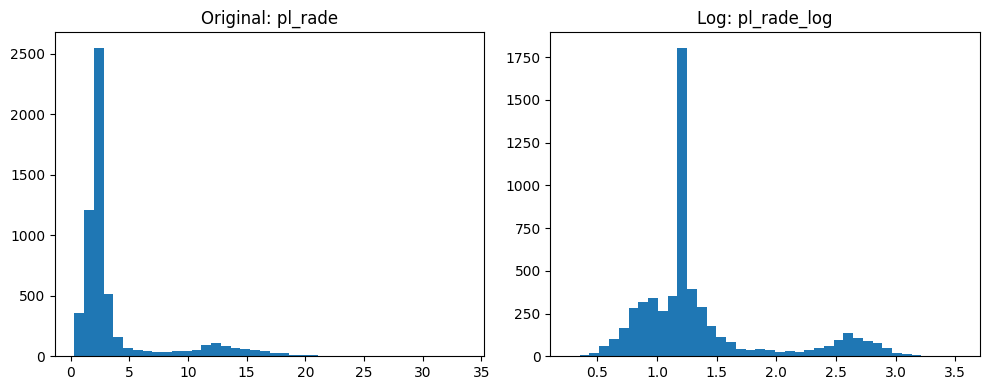

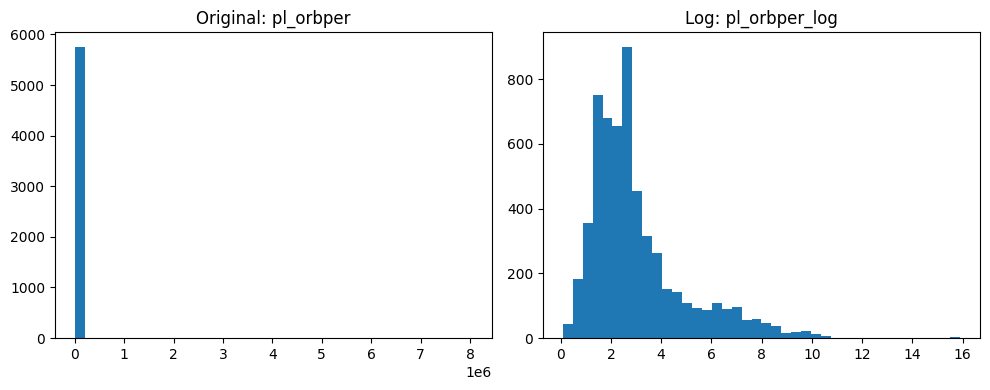

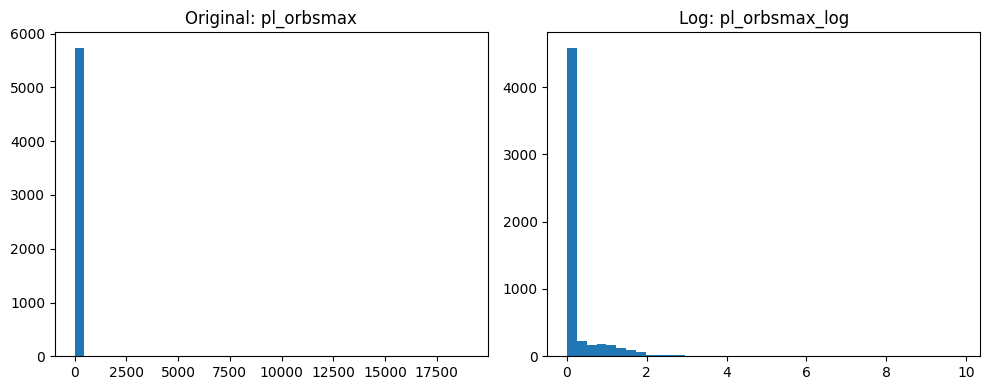

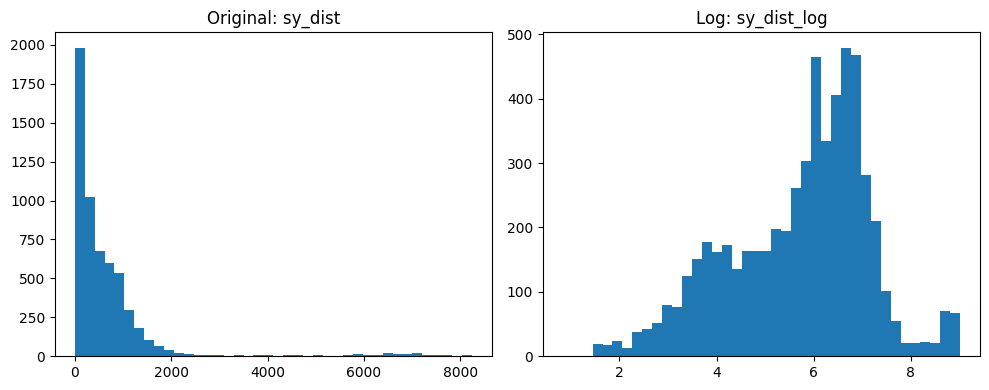

In [16]:
# ------------------------------------------------------------
# 16. Agrupar clases minoritarias en Other
# ------------------------------------------------------------

print("Distribución antes de agrupar clases minoritarias:")
target_counts_before_grouping = df[TARGET].value_counts()
mostrar(target_counts_before_grouping)

MIN_CLASS_SIZE = 100
minor_classes = target_counts_before_grouping[
    target_counts_before_grouping < MIN_CLASS_SIZE
].index.tolist()

print("\nClases agrupadas como Other:", minor_classes)

df[TARGET] = df[TARGET].apply(
    lambda x: "Other" if x in minor_classes else x
)

print("\nDistribución después de agrupar clases minoritarias:")
target_counts_after_grouping = df[TARGET].value_counts()
mostrar(target_counts_after_grouping)

plt.figure(figsize=(10, 5))
target_counts_after_grouping.plot(kind="bar")
plt.title("Distribución final de discoverymethod")
plt.xlabel("Método de descubrimiento")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 17. Detectar outliers sin eliminarlos automáticamente
# ------------------------------------------------------------

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_pct = outlier_count / len(df) * 100

    outlier_summary.append({
        "columna": col,
        "outliers": outlier_count,
        "porcentaje_outliers": outlier_pct,
        "limite_inferior": lower,
        "limite_superior": upper
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary = outlier_summary.sort_values("porcentaje_outliers", ascending=False)

print("\nTop 20 columnas con más outliers:")
mostrar(outlier_summary.head(20))

# ------------------------------------------------------------
# 18. Crear transformaciones logarítmicas
# ------------------------------------------------------------

log_candidate_cols = [
    "pl_bmasse", "pl_rade", "pl_orbper", "pl_orbsmax",
    "pl_insol", "pl_eqt", "sy_dist", "st_mass", "st_rad", "st_teff"
]

log_candidate_cols = [col for col in log_candidate_cols if col in df.columns]
created_log_cols = []

for col in log_candidate_cols:
    min_value = df[col].min()

    if min_value >= 0:
        log_col = f"{col}_log"
        df[log_col] = np.log1p(df[col])
        created_log_cols.append(log_col)
        print(f"Creada variable: {log_col}")
    else:
        print(f"No se creó log para {col}: contiene valores negativos")

# ------------------------------------------------------------
# 19. Graficar comparación original vs log
# ------------------------------------------------------------

vars_to_plot = [
    col for col in ["pl_bmasse", "pl_rade", "pl_orbper", "pl_orbsmax", "sy_dist"]
    if col in df.columns and f"{col}_log" in df.columns
]

for col in vars_to_plot:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(df[col], bins=40)
    plt.title(f"Original: {col}")

    plt.subplot(1, 2, 2)
    plt.hist(df[f"{col}_log"], bins=40)
    plt.title(f"Log: {col}_log")
    plt.tight_layout()
    plt.show()

## 7. Verificaciones Finales y Exportación
Consolidamos el resumen de todas las transformaciones y exportamos el dataset objetivo completamente limpio.

In [17]:
# ------------------------------------------------------------
# 20. Verificaciones finales y exportación
# ------------------------------------------------------------

print("Verificación final del dataset limpio")
print("-------------------------------------")
print(f"Shape final: {df.shape}")
print(f"Nulos finales: {df.isnull().sum().sum()}")
print(f"Duplicados finales: {df.duplicated().sum()}")
print(f"Cantidad de clases finales del target: {df[TARGET].nunique()}")

etl_summary = pd.DataFrame({
    "Métrica": [
        "Filas originales",
        "Columnas originales",
        "Filas finales",
        "Columnas finales",
        "Nulos finales",
        "Duplicados finales",
        "Clases finales del target",
        "Columnas eliminadas",
        "Columnas log creadas"
    ],
    "Valor": [
        df_raw.shape[0],
        df_raw.shape[1],
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df[TARGET].nunique(),
        len(cols_to_drop) + len(cols_high_null_to_drop),
        len(created_log_cols)
    ]
})

mostrar(etl_summary)

# Exportar dataset limpio
PROCESSED_DIR = "../Data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

OUTPUT_PATH = f"{PROCESSED_DIR}/NASA_Exoplanet_Clean_DiscoveryMethod.csv"

df.to_csv(OUTPUT_PATH, index=False)

print(f"\nDataset limpio exportado correctamente en: {OUTPUT_PATH}")

Verificación final del dataset limpio
-------------------------------------
Shape final: (5757, 42)
Nulos finales: 0
Duplicados finales: 0
Cantidad de clases finales del target: 4


,Métrica,Valor
0,Filas originales,36418
1,Columnas originales,91
2,Filas finales,5757
3,Columnas finales,42
4,Nulos finales,0
5,Duplicados finales,0
6,Clases finales del target,4
7,Columnas eliminadas,71
8,Columnas log creadas,9



Dataset limpio exportado correctamente en: ../Data/processed/NASA_Exoplanet_Clean_DiscoveryMethod.csv


## Conclusión del ETL

Se construyó un dataset objetivo para predecir el método de descubrimiento (`discoverymethod`) de exoplanetas. Las principales decisiones tomadas fueron:

- Se filtraron los registros canónicos mediante `default_flag = 1`, evitando múltiples filas para un mismo planeta.
- Se eliminaron identificadores, referencias, metadatos, columnas de error, columnas de límite y duplicados de unidades.
- Se eliminaron variables asociadas directamente al proceso de descubrimiento, como `disc_facility` y `disc_year`, para evitar que el modelo aprenda atajos no físicos.
- Se analizaron valores nulos y se crearon indicadores `_missing` en variables físicamente relevantes.
- Se imputaron variables numéricas con mediana global y variables categóricas con `Unknown`.
- No se utilizó `discoverymethod` para imputar variables predictoras, evitando fuga de información.
- Se agruparon clases minoritarias bajo la categoría `Other` para reducir dispersión del target.
- Se detectaron outliers sin eliminarlos automáticamente, ya que en el dominio astronómico muchos valores extremos pueden ser reales.
- Se generaron transformaciones logarítmicas para variables con alta dispersión.
- Se exportó el dataset limpio para etapas posteriores de EDA y modelado.

El resultado es un dataset consistente, sin nulos críticos, con target multiclase definido y preparado para análisis exploratorio y entrenamiento de modelos.